# 📈 Momentum Backtester
**Strategy**: Rank stocks by 12-1 month returns. Long top quintile, short bottom quintile. Rebalance monthly.

Used at: Citadel, Two Sigma, AQR

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

np.random.seed(42)

# --- Synthetic Price Data ---
n_stocks = 20
n_days = 756  # 3 years
dates = pd.date_range('2021-01-01', periods=n_days, freq='B')
tickers = [f'STK{i:02d}' for i in range(n_stocks)]

# Each stock has its own drift + vol
drifts = np.random.uniform(-0.0002, 0.0006, n_stocks)
vols   = np.random.uniform(0.01, 0.025, n_stocks)

returns = np.random.randn(n_days, n_stocks) * vols + drifts
prices  = pd.DataFrame(100 * np.exp(np.cumsum(returns, axis=0)),
                       index=dates, columns=tickers)

print(f'Price matrix: {prices.shape}')
prices.head()

Price matrix: (756, 20)


,STK00,STK01,STK02,STK03,STK04,STK05,STK06,STK07,STK08,STK09,STK10,STK11,STK12,STK13,STK14,STK15,STK16,STK17,STK18,STK19
2021-01-01,99.984080,98.784478,101.229049,98.153406,100.344823,95.814880,98.273729,100.398798,101.432943,100.220196,99.760893,99.679984,98.436160,98.267747,98.873094,102.361100,100.506241,98.020495,100.673521,99.365992
2021-01-04,98.704322,99.573662,102.780882,99.607865,98.929156,95.164681,98.682537,102.199165,100.547376,100.058022,97.655614,98.250371,99.364238,101.548030,98.693538,104.653784,101.041565,97.319565,101.428236,101.939330
2021-01-05,98.646357,101.532463,99.018564,100.912700,99.066840,94.539902,98.785113,98.712305,100.159222,100.477783,100.435010,97.669232,98.532297,100.317739,100.925042,105.412188,100.269060,97.915465,101.642748,103.595360
2021-01-06,97.336797,101.187671,98.499707,98.677497,99.554633,95.071758,98.776511,98.351440,97.544729,100.063357,99.760964,96.745869,98.403867,101.301771,105.689529,105.814514,100.650375,97.853433,97.780849,103.553183
2021-01-07,97.459004,104.305493,98.265461,99.167313,99.488971,92.675645,100.239007,99.719327,99.040764,99.131031,102.453115,95.112396,99.085911,106.821123,103.151472,104.491375,100.800983,97.311600,94.769956,103.674545


## Signal Construction
12-1 month momentum = return from t-252 to t-21 (skip last month to avoid reversal).

In [2]:
# Monthly rebalance dates
monthly = prices.resample('M').last()
monthly_ret = monthly.pct_change()

# 12-1 month momentum signal (11 month lookback on monthly data)
LOOKBACK = 11
signal = monthly.pct_change(LOOKBACK).shift(1)  # shift 1 = skip most recent month

print('Signal (first non-null row):')
print(signal.dropna().iloc[0].sort_values(ascending=False))

Signal (first non-null row):
STK08    0.627102
STK17    0.591940
STK03    0.366797
STK00    0.318186
STK07    0.262692
STK12    0.234028
STK09    0.225313
STK15    0.170818
STK11    0.160689
STK16    0.141361
STK02    0.108059
STK06    0.072548
STK04    0.007720
STK05   -0.043948
STK19   -0.150138
STK01   -0.196211
STK10   -0.199773
STK18   -0.235844
STK13   -0.278788
STK14   -0.573721
Name: 2022-01-31 00:00:00, dtype: float64


/tmp/ipykernel_938/2252076685.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = prices.resample('M').last()


## Portfolio Construction
Top quintile = Long, Bottom quintile = Short. Equal weight within each leg.

In [3]:
def build_portfolio(signal_row, q=0.2):
    """Return weight vector: +1/n_long for top quintile, -1/n_short for bottom."""
    s = signal_row.dropna()
    n = len(s)
    if n < 5:
        return pd.Series(0, index=signal_row.index)
    lo_cut = s.quantile(q)
    hi_cut = s.quantile(1 - q)
    weights = pd.Series(0.0, index=s.index)
    longs  = s[s >= hi_cut]
    shorts = s[s <= lo_cut]
    if len(longs):  weights[longs.index]  =  1 / len(longs)
    if len(shorts): weights[shorts.index] = -1 / len(shorts)
    return weights

# Build weights for each month
weights = signal.apply(build_portfolio, axis=1)
print('Sample weights:')
print(weights.dropna().iloc[0].to_frame('w').query('w != 0'))

Sample weights:
Empty DataFrame
Columns: [w]
Index: []


## Backtest Engine

In [4]:
# Align monthly returns with weights (weights known at start of month, applied next month)
strat_ret = (weights.shift(1) * monthly_ret).sum(axis=1)
strat_ret = strat_ret.dropna()

# Cumulative performance
cum_strat  = (1 + strat_ret).cumprod()
buy_hold   = (1 + monthly_ret.mean(axis=1).dropna()).cumprod()

print(f'Total Return : {cum_strat.iloc[-1]-1:.1%}')
print(f'Ann. Return  : {(cum_strat.iloc[-1]**(12/len(strat_ret))-1):.1%}')
print(f'Ann. Vol     : {strat_ret.std()*np.sqrt(12):.1%}')
print(f'Sharpe Ratio : {(strat_ret.mean()*12)/(strat_ret.std()*np.sqrt(12)):.2f}')
print(f'Max Drawdown : {((cum_strat/cum_strat.cummax())-1).min():.1%}')

Total Return : 5.5%
Ann. Return  : 1.9%
Ann. Vol     : 16.3%
Sharpe Ratio : 0.19
Max Drawdown : -14.8%


## Visualisation

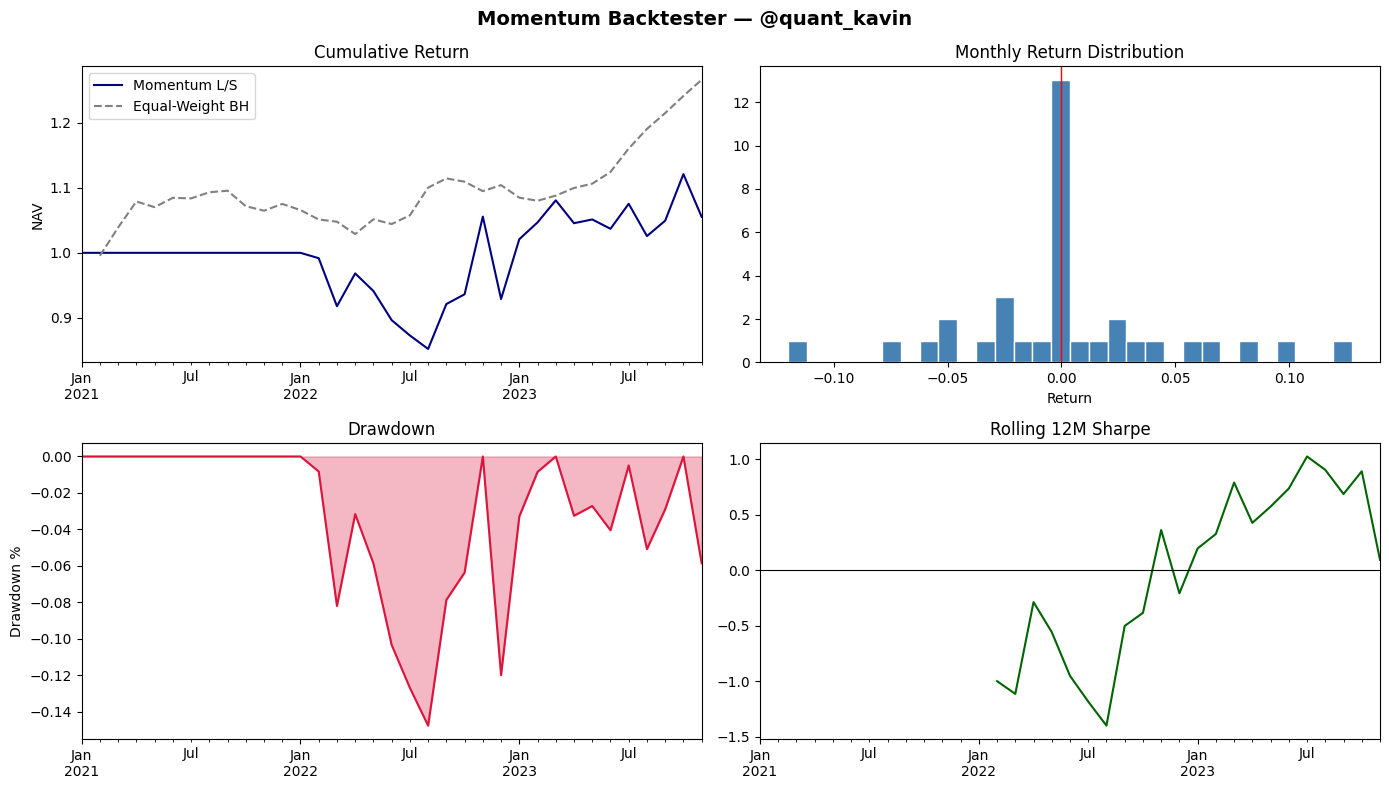

Done.


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Momentum Backtester — @quant_kavin', fontsize=14, fontweight='bold')

# 1. Cumulative returns
ax = axes[0,0]
cum_strat.plot(ax=ax, color='navy', label='Momentum L/S')
buy_hold.reindex(cum_strat.index).plot(ax=ax, color='gray', linestyle='--', label='Equal-Weight BH')
ax.set_title('Cumulative Return'); ax.legend(); ax.set_ylabel('NAV')

# 2. Monthly return distribution
ax = axes[0,1]
ax.hist(strat_ret, bins=30, color='steelblue', edgecolor='white')
ax.axvline(0, color='red', linewidth=1)
ax.set_title('Monthly Return Distribution'); ax.set_xlabel('Return')

# 3. Drawdown
ax = axes[1,0]
dd = (cum_strat / cum_strat.cummax()) - 1
dd.plot(ax=ax, color='crimson')
ax.fill_between(dd.index, dd, 0, alpha=0.3, color='crimson')
ax.set_title('Drawdown'); ax.set_ylabel('Drawdown %')

# 4. Rolling Sharpe (12m)
ax = axes[1,1]
rolling_sharpe = (strat_ret.rolling(12).mean() * 12) / (strat_ret.rolling(12).std() * np.sqrt(12))
rolling_sharpe.plot(ax=ax, color='darkgreen')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Rolling 12M Sharpe')

plt.tight_layout()
plt.savefig('/tmp/momentum.png', dpi=150, bbox_inches='tight')
plt.show()
print('Done.')